# Proyecto RappiPlus: de datos a decisiones de negocio

**Introducción**


El objetivo de este proyecto es evaluar el desempeño del servicio **RappiPlus** para apoyar **decisiones de negocio basadas en datos**.

Se trabajan con múltiples datasets del negocio:

- **rappiplus_orders_raw.csv** → información de pedidos, precios, descuentos y revenue  
- **rappiplus_catalog.csv** → costos de productos, categorías y proveedores  
- **rappiplus_marketing_spend.csv** → inversión en marketing por canal y país  
- **events / users / user_activity (SQL)** → comportamiento del usuario dentro de la plataforma  
- **experiment_checkout_ui.csv** → resultados de un experimento A/B en el checkout  

El análisis sigue una lógica clara y progresiva:

1. 🔍 Evaluar si podemos confiar en los datos (calidad de datos en Python)

2. 💰 Analizar si el negocio es rentable (revenue, costos y profit)  

3. 🛒 Entender dónde se pierden los usuarios (funnel de conversión)  

4. 🔁 Evaluar si los usuarios regresan (retención por cohortes)  

5. 🧪 Validar si los cambios generan impacto (test estadístico)  

6. 📊 Comunicar los resultados (dashboard en BI)  

A lo largo del proyecto, se transforman datos en insights para responder preguntas clave del negocio y proponer **recomendaciones accionables**.

---

## 🔹 Paso 1: Cargar librerias
---

In [ ]:
# importar librerías
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy.stats import ttest_ind
from scipy.stats import levene
from scipy.stats import chi2_contingency
from statsmodels.stats.proportion import proportions_ztest

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:** conocer la estructura de los datasets del negocio antes de analizarlos.

In [ ]:
# cargar archivos
orders = pd.read_csv('https://practicum-content.s3.amazonaws.com/datasets/rappiplus_orders_raw.csv')
catalog = pd.read_csv('https://practicum-content.s3.amazonaws.com/datasets/rappiplus_catalog.csv')
marketing = pd.read_csv('https://practicum-content.s3.amazonaws.com/datasets/rappiplus_marketing_spend.csv')

In [ ]:
# Examinar la estructura de orders
orders.info()
orders.head(5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25100 entries, 0 to 25099
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id_pedido           25100 non-null  object 
 1   id_usuario          25100 non-null  object 
 2   fecha_hora_pedido   25100 non-null  object 
 3   pais                24800 non-null  object 
 4   dispositivo         25080 non-null  object 
 5   fuente_referencia   25070 non-null  object 
 6   nombre_producto     25070 non-null  object 
 7   categoria_producto  25020 non-null  object 
 8   cantidad            25050 non-null  float64
 9   precio_unitario     25050 non-null  float64
 10  monto_descuento     25050 non-null  float64
 11  monto_total         25100 non-null  float64
dtypes: float64(4), object(8)
memory usage: 2.3+ MB


,id_pedido,id_usuario,fecha_hora_pedido,pais,dispositivo,fuente_referencia,nombre_producto,categoria_producto,cantidad,precio_unitario,monto_descuento,monto_total
0,order_0,user_6993,2025-05-22,Argentina,desktop,organic,Jacket-Winter-M,Moda,2.0,332.69,0.0,665.37
1,order_1,user_1329,2025-06-15,Mexico,desktop,paid_search,Tablet-Standard-64GB,Electronica,1.0,176.86,5.0,171.86
2,order_2,user_3194,2025-05-02,Argentina,desktop,social,Blender-XL-Red,Hogar,2.0,102.99,10.0,195.99
3,order_3,user_4510,2025-06-09,Colombia,mobile,social,Tablet-Standard-64GB,Electronica,1.0,257.87,15.0,242.87
4,order_4,user_5044,2025-03-30,Argentina,desktop,paid_search,Blender-XL-Red,Hogar,1.0,336.28,0.0,336.28


In [ ]:
# cantidad de nulos para orders
print(orders.isna().sum())

id_pedido               0
id_usuario              0
fecha_hora_pedido       0
pais                  300
dispositivo            20
fuente_referencia      30
nombre_producto        30
categoria_producto     80
cantidad               50
precio_unitario        50
monto_descuento        50
monto_total             0
dtype: int64


*✍🏼El Dataset **Orders** presenta las siguientes inconsistencias*

- Hay campos que no cuentan con los valores completos, debido a que se evidencian 25100 filas pero los campos: **pais**, **dispositivo**, **fuente_referencia**, **nombre_producto**, **categoria_producto**, **cantidad**, **precio_unitario**, **monto_descuento** no se encuentran completos.
- El campo **fecha_hora_pedido** este debe cambiar de object a **fecha**
- El campo **cantidad** debe ser un numero entero cambiar a **integer**
- El campo de **monto_descuento** debe ser numero entero cambiar a **integer**

In [ ]:
# Examinar la estructura de catalog
catalog.info()
catalog.head(5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   nombre_producto     7 non-null      object 
 1   categoria_producto  7 non-null      object 
 2   costo_unitario      7 non-null      float64
 3   proveedor           7 non-null      object 
dtypes: float64(1), object(3)
memory usage: 352.0+ bytes


,nombre_producto,categoria_producto,costo_unitario,proveedor
0,Laptop-Gaming-16GB,Electrónica,280.68,"Fuller, Pena and Myers"
1,Phone-Pro-128GB,Electrónica,10.12,King Ltd
2,Tablet-Standard-64GB,Electrónica,25.21,Bowers LLC
3,Blender-XL-Red,Hogar,176.64,Long-Reid
4,Vacuum-Pro-Black,Hogar,16.60,"Rivera, Carr and Finley"


In [ ]:
# cantidad de nulos para catalog
print(catalog.isna().sum())

nombre_producto       0
categoria_producto    0
costo_unitario        0
proveedor             0
dtype: int64


*✍🏼El Dataset **Catalog** no presenta inconsistencias en tipos de dato y/o valores nulos*

In [ ]:
# Examinar la estructura de orders marketing
marketing.info()
marketing.head(5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1620 entries, 0 to 1619
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   fecha       1620 non-null   object 
 1   pais        1620 non-null   object 
 2   id_campaña  1620 non-null   object 
 3   canal       1519 non-null   object 
 4   gasto       1620 non-null   float64
dtypes: float64(1), object(4)
memory usage: 63.4+ KB


,fecha,pais,id_campaña,canal,gasto
0,2025-01-01,Mexico,organic_Mexico,organic,2446.25
1,2025-01-01,Mexico,paid_search_Mexico,paid_search,2704.34
2,2025-01-01,Mexico,social_Mexico,social,2045.01
3,2025-01-01,Colombia,organic_Colombia,organic,2597.21
4,2025-01-01,Colombia,paid_search_Colombia,paid_search,1771.40


In [ ]:
# cantidad de nulos para marketing
print(marketing.isna().sum())

fecha           0
pais            0
id_campaña      0
canal         101
gasto           0
dtype: int64


*✍🏼El Dataset **marketing** presenta las siguientes inconsistencias*
- Hay campos un campo que no cuenta con el total de los datos, debido a que se evidencian 1620 filas pero en el campos: **canal** son menos datos 1519.
- El campo **fecha** este debe cambiar de object a **fecha**

---

### Revisión y calidad de datos

**🎯 Objetivo:** Detectar y corregir problemas en los datos que puedan afectar el análisis de revenue, costos y rentabilidad.
---

In [ ]:
# Convertir las columnas de orders a tipo fecha con pd.to_datetime()
orders['fecha_hora_pedido'] = pd.to_datetime(orders['fecha_hora_pedido'])
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25100 entries, 0 to 25099
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   id_pedido           25100 non-null  object        
 1   id_usuario          25100 non-null  object        
 2   fecha_hora_pedido   25100 non-null  datetime64[ns]
 3   pais                24800 non-null  object        
 4   dispositivo         25080 non-null  object        
 5   fuente_referencia   25070 non-null  object        
 6   nombre_producto     25070 non-null  object        
 7   categoria_producto  25020 non-null  object        
 8   cantidad            25050 non-null  float64       
 9   precio_unitario     25050 non-null  float64       
 10  monto_descuento     25050 non-null  float64       
 11  monto_total         25100 non-null  float64       
dtypes: datetime64[ns](1), float64(4), object(7)
memory usage: 2.3+ MB


In [ ]:
# Variables categóricas de orders
columnas_category_Orders = orders[
    ['pais', 'dispositivo', 'fuente_referencia',
     'nombre_producto', 'categoria_producto']
]

# explorar cada variable categorica de orders y determinar el porcentaje con 2 decimales
for columna in columnas_category_Orders.columns:

    print(f"\n{'='*50}")
    print(f"Variable: {columna}")
    print(f"{'='*50}")

    # Porcentaje de participación
    porcentajes = (
        columnas_category_Orders[columna]
        .value_counts(normalize=True, dropna=False)
        .mul(100)
        .round(2)
    )

    print(porcentajes)


Variable: pais
Colombia     29.96
Mexico       29.89
Argentina    29.05
mexico        3.45
colombia      3.28
argentina     3.18
NaN           1.20
Name: pais, dtype: float64

Variable: dispositivo
desktop    50.83
mobile     49.09
NaN         0.08
Name: dispositivo, dtype: float64

Variable: fuente_referencia
social         33.58
organic        33.18
paid_search    33.12
NaN             0.12
Name: fuente_referencia, dtype: float64

Variable: nombre_producto
Vacuum-Pro-Black        16.73
Blender-XL-Red          16.71
Jacket-Winter-M         16.70
Sneakers-Urban-42       16.57
Laptop-Gaming-16GB      11.13
Tablet-Standard-64GB    11.08
Phone-Pro-128GB         10.96
NaN                      0.12
Name: nombre_producto, dtype: float64

Variable: categoria_producto
Hogar          33.41
Moda           33.16
Electronica    33.12
NaN             0.32
Name: categoria_producto, dtype: float64


In [ ]:
#estandarizar las categorias de pais en el dataset de orders
orders['pais'] = (
    orders['pais']
    .str.strip()
    .str.upper()
)

In [ ]:
#verficar cambio
orders['pais'].value_counts(normalize=True, dropna=False)

MEXICO       0.333347
COLOMBIA     0.332390
ARGENTINA    0.322311
NaN          0.011952
Name: pais, dtype: float64

In [ ]:
# rellenar los valores faltantes con no informado
orders['pais'] = orders['pais'].fillna('NO INFORMADO')

In [ ]:
#verficar cambio
orders['pais'].value_counts(normalize=True, dropna=False)

MEXICO          0.333347
COLOMBIA        0.332390
ARGENTINA       0.322311
NO INFORMADO    0.011952
Name: pais, dtype: float64

In [ ]:
#bucle para recorrer los demas atributos para rellenar los valores faltantes con No informado, debido a que no se encontro valores de moda que puedan ser empleados para su llenado.

columnas_no_informadas = [
    'dispositivo',
    'fuente_referencia',
    'nombre_producto',
    'categoria_producto'
]
for columna in columnas_no_informadas:
    orders[columna] = orders[columna].fillna('NO INFORMADO')

In [ ]:
# Variables categóricas de orders
columnas_category_Orders = orders[
    ['pais', 'dispositivo', 'fuente_referencia',
     'nombre_producto', 'categoria_producto']
]

# explorar cada variable categorica de orders y determinar el porcentaje con 2 decimales
for columna in columnas_category_Orders.columns:

    print(f"\n{'='*50}")
    print(f"Variable: {columna}")
    print(f"{'='*50}")

    # Porcentaje de participación
    porcentajes = (
        columnas_category_Orders[columna]
        .value_counts(normalize=True, dropna=False)
        .mul(100)
        .round(2)
    )

    print(porcentajes)


Variable: pais
MEXICO          33.33
COLOMBIA        33.24
ARGENTINA       32.23
NO INFORMADO     1.20
Name: pais, dtype: float64

Variable: dispositivo
desktop         50.83
mobile          49.09
NO INFORMADO     0.08
Name: dispositivo, dtype: float64

Variable: fuente_referencia
social          33.58
organic         33.18
paid_search     33.12
NO INFORMADO     0.12
Name: fuente_referencia, dtype: float64

Variable: nombre_producto
Vacuum-Pro-Black        16.73
Blender-XL-Red          16.71
Jacket-Winter-M         16.70
Sneakers-Urban-42       16.57
Laptop-Gaming-16GB      11.13
Tablet-Standard-64GB    11.08
Phone-Pro-128GB         10.96
NO INFORMADO             0.12
Name: nombre_producto, dtype: float64

Variable: categoria_producto
Hogar           33.41
Moda            33.16
Electronica     33.12
NO INFORMADO     0.32
Name: categoria_producto, dtype: float64


In [ ]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25100 entries, 0 to 25099
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   id_pedido           25100 non-null  object        
 1   id_usuario          25100 non-null  object        
 2   fecha_hora_pedido   25100 non-null  datetime64[ns]
 3   pais                25100 non-null  object        
 4   dispositivo         25100 non-null  object        
 5   fuente_referencia   25100 non-null  object        
 6   nombre_producto     25100 non-null  object        
 7   categoria_producto  25100 non-null  object        
 8   cantidad            25050 non-null  float64       
 9   precio_unitario     25050 non-null  float64       
 10  monto_descuento     25050 non-null  float64       
 11  monto_total         25100 non-null  float64       
dtypes: datetime64[ns](1), float64(4), object(7)
memory usage: 2.3+ MB


In [ ]:
# tratamiento para nulo de los atributos numericos en cantidad
orders['cantidad'].isna().mean()

0.00199203187250996

In [ ]:
orders['cantidad'].describe()

count    25050.000000
mean         7.092735
std        296.277003
min         -2.000000
25%          1.000000
50%          2.000000
75%          2.000000
max      20000.000000
Name: cantidad, dtype: float64

In [ ]:
# determinar cuantos valores estan negativos
(orders['cantidad'] < 0).sum()

4

In [ ]:
# convertir en valores absolutos
orders['cantidad'] = orders['cantidad'].abs()

In [ ]:
orders['cantidad'].describe()

count    25050.000000
mean         7.093134
std        296.276993
min          1.000000
25%          1.000000
50%          2.000000
75%          2.000000
max      20000.000000
Name: cantidad, dtype: float64

In [ ]:
# determinar cuantos valores hay mayores a 100
(orders['cantidad'] > 100).sum()

10

In [ ]:
# identificar los valores iguales a 2000
(orders['cantidad'] == 2000)

0        False
1        False
2        False
3        False
4        False
         ...  
25095    False
25096    False
25097    False
25098    False
25099    False
Name: cantidad, Length: 25100, dtype: bool

In [ ]:
# Asigna NaN únicamente en las filas donde 'cantidad' es igual a 20000
orders.loc[orders['cantidad'] == 20000, 'cantidad'] = np.nan

In [ ]:
orders['cantidad'].describe()

count    25046.000000
mean         3.900144
std        154.739071
min          1.000000
25%          1.000000
50%          2.000000
75%          2.000000
max      10000.000000
Name: cantidad, dtype: float64

In [ ]:
# identificar los valores iguales a 2000
(orders['cantidad'] == 10000).sum()

6

In [ ]:
# Asigna NaN únicamente en las filas donde 'cantidad' es igual a 10000
orders.loc[orders['cantidad'] == 10000, 'cantidad'] = np.nan

In [ ]:
orders['cantidad'].describe()

count    25040.000000
mean         1.504912
std          0.499986
min          1.000000
25%          1.000000
50%          2.000000
75%          2.000000
max          2.000000
Name: cantidad, dtype: float64

In [ ]:
# reemplazar los valores nulos por la mediana que es 2
orders['cantidad'] = orders['cantidad'].fillna(2)

In [ ]:
# verficar la limpieza de los nulos para el atributo cantidad
orders['cantidad'].isna().sum()

0

In [ ]:
# tratamiento para nulo de los atributos numericos en precio_unitario
orders['precio_unitario'].isna().mean()

0.00199203187250996

In [ ]:
orders['precio_unitario'].describe()

count    25050.000000
mean       259.305549
std        138.726461
min         20.030000
25%        138.377500
50%        258.715000
75%        380.332500
max        499.960000
Name: precio_unitario, dtype: float64

In [ ]:
#reemplazar los valores nulos por la mediana en este caso es 258.71
orders['precio_unitario'] = orders['precio_unitario'].fillna(orders['precio_unitario'].median())

In [ ]:
# verficar la limpieza de los nulos para el atributo precio_unitario
orders['precio_unitario'].isna().sum()

0

In [ ]:
# tratamiento para nulo de los atributos numericos en monto_descuento
orders['monto_descuento'].isna().mean()

0.00199203187250996

In [ ]:
orders['monto_descuento'].describe()

count    25050.000000
mean         4.500798
std          5.223010
min          0.000000
25%          0.000000
50%          0.000000
75%         10.000000
max         15.000000
Name: monto_descuento, dtype: float64

In [ ]:
# determinar la moda con el fin de reemplazar los valores nulos con este valor.
orders['monto_descuento'].mode()

0    0.0
dtype: float64

In [ ]:
#reemplazar los valores nulos por la moda en este caso es cero.
orders['monto_descuento'] = orders['monto_descuento'].fillna(0)

In [ ]:
# verificar nulos en el atributo.
orders['monto_descuento'].isna().sum()

0

In [ ]:
# Convertir las columnas a entero
orders[['cantidad', 'monto_descuento']] = orders[['cantidad', 'monto_descuento']].astype(int)

In [ ]:
# verificar la limpieza de datos en orders en conversion de tipo de columnas y nulos.
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25100 entries, 0 to 25099
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   id_pedido           25100 non-null  object        
 1   id_usuario          25100 non-null  object        
 2   fecha_hora_pedido   25100 non-null  datetime64[ns]
 3   pais                25100 non-null  object        
 4   dispositivo         25100 non-null  object        
 5   fuente_referencia   25100 non-null  object        
 6   nombre_producto     25100 non-null  object        
 7   categoria_producto  25100 non-null  object        
 8   cantidad            25100 non-null  int64         
 9   precio_unitario     25100 non-null  float64       
 10  monto_descuento     25100 non-null  int64         
 11  monto_total         25100 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(2), object(7)
memory usage: 2.3+ MB


In [ ]:
# Convertir las columnas del dataset marketing a tipo fecha con pd.to_datetime()
marketing['fecha'] = pd.to_datetime(marketing['fecha'])

# verificar el cambio
marketing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1620 entries, 0 to 1619
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   fecha       1620 non-null   datetime64[ns]
 1   pais        1620 non-null   object        
 2   id_campaña  1620 non-null   object        
 3   canal       1519 non-null   object        
 4   gasto       1620 non-null   float64       
dtypes: datetime64[ns](1), float64(1), object(3)
memory usage: 63.4+ KB


In [ ]:
# exploracion de valores nulos en las columnas categoricas del dataset marketing
marketing['canal'].value_counts(normalize=True)

paid_search    0.333772
social         0.333114
organic        0.333114
Name: canal, dtype: float64

In [ ]:
# Reemplazar valores nulos por 'Desconocido'
marketing['canal'] = marketing['canal'].fillna('Desconocido')

In [ ]:
marketing['pais'].value_counts(normalize=True, dropna=False)

Colombia     0.333333
Argentina    0.333333
Mexico       0.333333
Name: pais, dtype: float64

In [ ]:
#estandarizar las categorias de pais en el dataset de marketing
marketing['pais'] = (
    marketing['pais']
    .str.strip()
    .str.upper()
)

In [ ]:
# Verificar cambios
print(marketing['canal'].isna().sum())
print(marketing['canal'].value_counts())

0
paid_search    507
social         506
organic        506
Desconocido    101
Name: canal, dtype: int64


In [ ]:
# Variables categóricas de marketing
columnas_category_marketing = marketing[
    ['pais', 'canal']
]

# explorar cada variable categorica de catalog y determinar el porcentaje con 2 decimales
for columna in columnas_category_marketing.columns:

    print(f"\n{'='*50}")
    print(f"Variable: {columna}")
    print(f"{'='*50}")

    # Porcentaje de participación
    porcentajes = (
        columnas_category_marketing[columna]
        .value_counts(normalize=True, dropna=False)
        .mul(100)
        .round(2)
    )

    print(porcentajes)


Variable: pais
MEXICO       33.33
ARGENTINA    33.33
COLOMBIA     33.33
Name: pais, dtype: float64

Variable: canal
paid_search    31.30
social         31.23
organic        31.23
Desconocido     6.23
Name: canal, dtype: float64


In [ ]:
#verificar el cambio y valores nulos
catalog.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   nombre_producto     7 non-null      object 
 1   categoria_producto  7 non-null      object 
 2   costo_unitario      7 non-null      float64
 3   proveedor           7 non-null      object 
dtypes: float64(1), object(3)
memory usage: 352.0+ bytes


In [ ]:
# Variables categóricas de catalog
columnas_category_catalog = catalog[
    ['nombre_producto', 'categoria_producto', 'proveedor']
]

# explorar cada variable categorica de catalog y determinar el porcentaje con 2 decimales
for columna in columnas_category_catalog.columns:

    print(f"\n{'='*50}")
    print(f"Variable: {columna}")
    print(f"{'='*50}")

    # Porcentaje de participación
    porcentajes = (
        columnas_category_catalog[columna]
        .value_counts(normalize=True, dropna=False)
        .mul(100)
        .round(2)
    )

    print(porcentajes)


Variable: nombre_producto
Blender-XL-Red          14.29
Jacket-Winter-M         14.29
Phone-Pro-128GB         14.29
Sneakers-Urban-42       14.29
Laptop-Gaming-16GB      14.29
Vacuum-Pro-Black        14.29
Tablet-Standard-64GB    14.29
Name: nombre_producto, dtype: float64

Variable: categoria_producto
Electrónica    42.86
Hogar          28.57
Moda           28.57
Name: categoria_producto, dtype: float64

Variable: proveedor
Mcmillan-Rhodes            14.29
Fuller, Pena and Myers     14.29
Bowers LLC                 14.29
Rivera, Carr and Finley    14.29
Long-Reid                  14.29
King Ltd                   14.29
Greene-Smith               14.29
Name: proveedor, dtype: float64


In [ ]:
# Es necesario reemplazar Electrónica y eliminar la tilde
catalog['categoria_producto'] = catalog['categoria_producto'].str.replace('Electrónica', 'Electronica')

In [ ]:
# Variables categóricas de catalog
columnas_category_catalog = catalog[
    ['nombre_producto', 'categoria_producto', 'proveedor']
]

# explorar cada variable categorica de catalog y determinar el porcentaje con 2 decimales
for columna in columnas_category_catalog.columns:

    print(f"\n{'='*50}")
    print(f"Variable: {columna}")
    print(f"{'='*50}")

    # Porcentaje de participación
    porcentajes = (
        columnas_category_catalog[columna]
        .value_counts(normalize=True, dropna=False)
        .mul(100)
        .round(2)
    )

    print(porcentajes)


Variable: nombre_producto
Blender-XL-Red          14.29
Jacket-Winter-M         14.29
Phone-Pro-128GB         14.29
Sneakers-Urban-42       14.29
Laptop-Gaming-16GB      14.29
Vacuum-Pro-Black        14.29
Tablet-Standard-64GB    14.29
Name: nombre_producto, dtype: float64

Variable: categoria_producto
Electronica    42.86
Hogar          28.57
Moda           28.57
Name: categoria_producto, dtype: float64

Variable: proveedor
Mcmillan-Rhodes            14.29
Fuller, Pena and Myers     14.29
Bowers LLC                 14.29
Rivera, Carr and Finley    14.29
Long-Reid                  14.29
King Ltd                   14.29
Greene-Smith               14.29
Name: proveedor, dtype: float64


## Dataset limpios

A continuacion se mostrara la informacion de cada dataset en donde se verificara el tratamiento de estandarizacion de datos y nulos

In [ ]:
orders.info()
orders.head(5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25100 entries, 0 to 25099
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   id_pedido           25100 non-null  object        
 1   id_usuario          25100 non-null  object        
 2   fecha_hora_pedido   25100 non-null  datetime64[ns]
 3   pais                25100 non-null  object        
 4   dispositivo         25100 non-null  object        
 5   fuente_referencia   25100 non-null  object        
 6   nombre_producto     25100 non-null  object        
 7   categoria_producto  25100 non-null  object        
 8   cantidad            25100 non-null  int64         
 9   precio_unitario     25100 non-null  float64       
 10  monto_descuento     25100 non-null  int64         
 11  monto_total         25100 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(2), object(7)
memory usage: 2.3+ MB


,id_pedido,id_usuario,fecha_hora_pedido,pais,dispositivo,fuente_referencia,nombre_producto,categoria_producto,cantidad,precio_unitario,monto_descuento,monto_total
0,order_0,user_6993,2025-05-22,ARGENTINA,desktop,organic,Jacket-Winter-M,Moda,2,332.69,0,665.37
1,order_1,user_1329,2025-06-15,MEXICO,desktop,paid_search,Tablet-Standard-64GB,Electronica,1,176.86,5,171.86
2,order_2,user_3194,2025-05-02,ARGENTINA,desktop,social,Blender-XL-Red,Hogar,2,102.99,10,195.99
3,order_3,user_4510,2025-06-09,COLOMBIA,mobile,social,Tablet-Standard-64GB,Electronica,1,257.87,15,242.87
4,order_4,user_5044,2025-03-30,ARGENTINA,desktop,paid_search,Blender-XL-Red,Hogar,1,336.28,0,336.28


In [ ]:
marketing.info()
marketing.head(5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1620 entries, 0 to 1619
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   fecha       1620 non-null   datetime64[ns]
 1   pais        1620 non-null   object        
 2   id_campaña  1620 non-null   object        
 3   canal       1620 non-null   object        
 4   gasto       1620 non-null   float64       
dtypes: datetime64[ns](1), float64(1), object(3)
memory usage: 63.4+ KB


,fecha,pais,id_campaña,canal,gasto
0,2025-01-01,MEXICO,organic_Mexico,organic,2446.25
1,2025-01-01,MEXICO,paid_search_Mexico,paid_search,2704.34
2,2025-01-01,MEXICO,social_Mexico,social,2045.01
3,2025-01-01,COLOMBIA,organic_Colombia,organic,2597.21
4,2025-01-01,COLOMBIA,paid_search_Colombia,paid_search,1771.40


In [ ]:
catalog.info()
catalog.head(5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   nombre_producto     7 non-null      object 
 1   categoria_producto  7 non-null      object 
 2   costo_unitario      7 non-null      float64
 3   proveedor           7 non-null      object 
dtypes: float64(1), object(3)
memory usage: 352.0+ bytes


,nombre_producto,categoria_producto,costo_unitario,proveedor
0,Laptop-Gaming-16GB,Electronica,280.68,"Fuller, Pena and Myers"
1,Phone-Pro-128GB,Electronica,10.12,King Ltd
2,Tablet-Standard-64GB,Electronica,25.21,Bowers LLC
3,Blender-XL-Red,Hogar,176.64,Long-Reid
4,Vacuum-Pro-Black,Hogar,16.60,"Rivera, Carr and Finley"


---
**📦 Exportación**: Una vez finalizada la limpieza, se exportan los datasets para utilizarlos en la última etapa del proyecto.

---

In [ ]:
# exportar datasets
orders.to_csv('orders_clean.csv', index=False)
catalog.to_csv('catalog_clean.csv', index=False)
marketing.to_csv('marketing_clean.csv', index=False)

## 🔹 Paso 2: Analizar si el negocio es rentable

### 2.1 Cálculo de KPIs principales

**🎯 Objetivo:** Calcular los indicadores clave del negocio para evaluar ingresos, costos y rentabilidad.

In [ ]:
# Seleccionar columnas clave de Orders y catalog

left_cols = ['id_pedido','id_usuario','fecha_hora_pedido',"pais", "categoria_producto", 'nombre_producto', "cantidad", "precio_unitario", "monto_descuento", "monto_total"]

right_cols = ['nombre_producto','costo_unitario','proveedor']

# Usar .copy() para crear los dos nuevos datasets reducidos

orders_small = orders[left_cols].copy()
catalog_small = catalog[right_cols].copy()

# Unir datasets
merged = pd.merge(orders_small, catalog_small, on=['nombre_producto'], how='left')

# Mostrar las primeras 5 filas
merged.head(5)


,id_pedido,id_usuario,fecha_hora_pedido,pais,categoria_producto,nombre_producto,cantidad,precio_unitario,monto_descuento,monto_total,costo_unitario,proveedor
0,order_0,user_6993,2025-05-22,ARGENTINA,Moda,Jacket-Winter-M,2,332.69,0,665.37,189.31,Mcmillan-Rhodes
1,order_1,user_1329,2025-06-15,MEXICO,Electronica,Tablet-Standard-64GB,1,176.86,5,171.86,25.21,Bowers LLC
2,order_2,user_3194,2025-05-02,ARGENTINA,Hogar,Blender-XL-Red,2,102.99,10,195.99,176.64,Long-Reid
3,order_3,user_4510,2025-06-09,COLOMBIA,Electronica,Tablet-Standard-64GB,1,257.87,15,242.87,25.21,Bowers LLC
4,order_4,user_5044,2025-03-30,ARGENTINA,Hogar,Blender-XL-Red,1,336.28,0,336.28,176.64,Long-Reid


In [ ]:
merged[merged['costo_unitario'].isna()][['nombre_producto']].value_counts()

nombre_producto
NO INFORMADO       30
dtype: int64

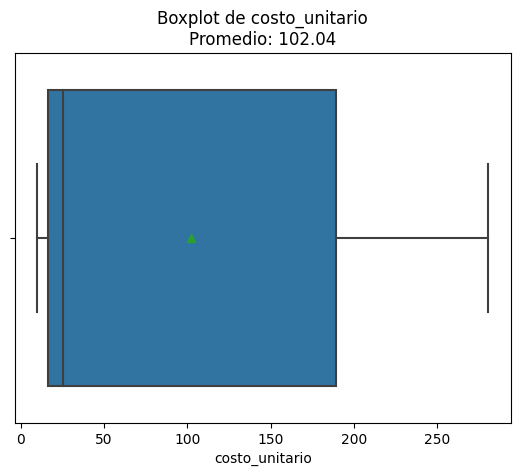

In [ ]:

# boxplot para observar el comportamiento de costos unitarios

sns.boxplot(data= merged, x='costo_unitario',showmeans=True)

# obtener promedio para mostrarlo en título
mean_value = merged['costo_unitario'].mean()
plt.title(f'Boxplot de costo_unitario\nPromedio: {mean_value:.2f}')
plt.show()


Cuando una distribución está sesgada hacia la derecha (con valores extremos altos), la mediana es más robusta para imputar los valores nulos porque:

Solo depende de la posición central de los datos ordenados, no de sus valores exactos.
Los valores extremos (outliers) no la "arrastran" hacia arriba como sí le sucede a la media.
Por eso, para imputar los 30 valores nulos en "costo_unitario", la mediana representa mejor el valor "típico" de tus datos.

In [ ]:
merged['costo_unitario'].median()

25.21

In [ ]:
# reemplazar los valores nulos por la mediana que es 25.21
merged['costo_unitario']= merged['costo_unitario'].fillna(merged['costo_unitario'].median())

In [ ]:
merged['costo_unitario'].isna().sum()

0

### KPI's:
¿Cuál es el ingreso total (revenue)?
¿Cuál es el costo total?

In [ ]:
ingresos_totales = merged['monto_total'].sum()
# Mostrar resultados
print(f"Ingresos Totales: ${ingresos_totales:,.2f}")

Ingresos Totales: $52,024,257.56


In [ ]:
# Costo total
merged['costo_total'] = merged['costo_unitario'] * merged['cantidad']
# Costo total acumulado
costos_totales_sum = merged['costo_total'].sum()
print(f"Costos Totales: ${costos_totales_sum:,.2f}")

Costos Totales: $3,860,527.19


In [ ]:
#inversion en marketing
marketing_inversion = marketing['gasto'].sum()
# Mostrar resultados
print(f"inversion de Marketing:     ${marketing_inversion:,.2f}")

inversion de Marketing:     $2,871,843.53


In [ ]:
# Nueva columna Profit individual por transacción
merged['profit'] = merged['monto_total'] - merged['costo_total']

# Profit total acumulado (Ingresos Totales - Costos Totales)
costos_totales_sum = merged['costo_total'].sum()
profit_total = ingresos_totales - costos_totales_sum

# Mostrar resultados
print(f"Profit Total:     ${profit_total:,.2f}")



Profit Total:     $48,163,730.37


In [ ]:

# Profit Neto
profit_neto = profit_total - marketing_inversion

# Mostrar resultados
print(f"profit_neto:     ${profit_neto:,.2f}")


profit_neto:     $45,291,886.84


In [ ]:
print(merged.shape[0])
print(merged['id_pedido'].nunique())

25100
25000


In [ ]:
# Promedio del ticket promedio de ventas
ticket_promedio = ingresos_totales / merged['id_pedido'].nunique()
print(f"Ticket Promedio: ${ticket_promedio:,.2f}")

Ticket Promedio: $2,080.97


In [ ]:
# cantidad de productos promedio por compra
productos_promedio = merged['cantidad'].sum() / merged['id_pedido'].nunique()
print(f"productos_promedio: {productos_promedio:,.2f}")

productos_promedio: 1.51


In [ ]:
# Agrupar por nombre de producto y sumar la cantidad vendida

ventas_por_producto = merged.groupby('nombre_producto')['cantidad'].sum()

# Obtener el producto con mayor cantidad de unidades vendidas
producto_mas_vendido = ventas_por_producto.idxmax()
cantidad_maxima = ventas_por_producto.max()

print(f"El producto más vendido es: {producto_mas_vendido} ({cantidad_maxima} unidades)")

El producto más vendido es: Vacuum-Pro-Black (6329 unidades)


In [ ]:
# Agrupar por canal en marketing y sumar los gastos
canal_agrupado = (
    marketing.groupby('canal')['gasto']
    .sum()
    .reset_index()
    .sort_values(by='gasto', ascending=False)
)
print(canal_agrupado)


         canal      gasto
3       social  918043.21
1      organic  913533.01
2  paid_search  863088.21
0  Desconocido  177179.10


### KPIs resumen:
- Ingresos Totales: **$52,024,257.56**

- Costos Totales: **$3,860,527.19**

- Profit Total (Ingresos - Costos): **$48,163,730.37**

- Inversión en Marketing: **$2,871,843.53**

- Profit Neto (Profit Total - Marketing): **$45,291,886.84**

- Ticket Promedio: **$2,080.97**

- productos_promedio: 1.51

- El producto más vendido es: Vacuum-Pro-Black (6329 unidades)

- Canal con mas gastos en marketing (social, organic, paid_search)


---

## 🔹 Paso 3: Entender dónde se pierden los usuarios (funnel de conversión)

**🎯 Objetivo:** Analizar el comportamiento de los usuarios para identificar en qué etapa del proceso se pierden.


⚙️**Conexión a la base de datos**:  
Se ejecuta la línea de configuración para conectar con la base de datos y aplicar consultas SQL en la tabla **events**.

---

In [ ]:

import pandas as pd
from sqlalchemy import create_engine

# ======================
# Conexión (NO modificar)
# ======================
db_config = {
    'user': 'practicum_student',
    'pwd': 'QnmDH8Sc2TQLvy2G3Vvh7',
    'host': 'yp-trainers-practicum.cluster-czs0gxyx2d8w.us-east-1.rds.amazonaws.com',
    'port': 5432,
    'db': 'data-analyst-production-db-en'
}

connection_string = 'postgresql://{}:{}@{}:{}/{}'.format(
    db_config['user'],
    db_config['pwd'],
    db_config['host'],
    db_config['port'],
    db_config['db']
)

engine = create_engine(connection_string, connect_args={'sslmode':'require'})


In [ ]:
# Explorar tabla events
# =========================
query_events = '''
SELECT *
FROM events;
'''
events = pd.read_sql(query_events, con=engine)
events.head()

,id_usuario,id_sesion,nombre_evento,timestamp_evento,pais,dispositivo,fuente_referencia,categoria_producto
0,user_6772,6a97f2af-32ae-4186-8c92-04025be1a27b,first_visit,2025-05-17,Colombia,desktop,organic,Moda
1,user_5883,369b767c-1c33-4b2f-a652-c7c0ef92cfc9,add_to_cart,2025-02-23,Mexico,mobile,social,Hogar
2,user_5946,60039041-e78b-474c-87b3-c0b7e9c30708,add_payment_info,2025-05-15,Colombia,desktop,social,Electronica
3,user_827,18252a64-f389-4ef7-9e58-dadad4a3491e,purchase,2025-03-31,Mexico,mobile,social,Moda
4,user_2361,221b364e-cdc5-4668-b698-18d5ba849a67,first_visit,2025-01-22,Argentina,desktop,paid_search,Electronica


In [ ]:
# PARTE 1: Totales del funnel
# ======================
query_totals = '''
WITH eventos_unicos AS (
    SELECT DISTINCT nombre_evento
    FROM events
)
SELECT nombre_evento
FROM eventos_unicos
ORDER BY CASE nombre_evento
    WHEN 'first_visit' THEN 1
    WHEN 'select_item' THEN 2
    WHEN 'add_to_cart' THEN 3
    WHEN 'begin_checkout' THEN 4
    WHEN 'add_payment_info' THEN 5
    WHEN 'purchase' THEN 6
    ELSE 7 -- Envía cualquier otro evento imprevisto al final
END;
'''
totals = pd.read_sql(query_totals, con=engine)
totals

,nombre_evento
0,first_visit
1,select_item
2,add_to_cart
3,begin_checkout
4,add_payment_info
5,purchase


El funnel consta de 5 etapas iniciando en primera visita y finalizando con compra.

In [ ]:
# PARTE 1: Usuarios unicos del funnel segun evento
# ======================
query_conversion = '''
SELECT
    nombre_evento,
    COUNT(DISTINCT id_usuario) AS usuarios_unicos
FROM events
GROUP BY nombre_evento
ORDER BY usuarios_unicos DESC;
'''
conversion = pd.read_sql(query_conversion, con=engine)
conversion

,nombre_evento,usuarios_unicos
0,first_visit,7796
1,add_to_cart,7634
2,select_item,7582
3,begin_checkout,7208
4,add_payment_info,6250
5,purchase,6240


Es de resaltar el numero de usuarios que existe en la etapa de select_item (7582) el cual resulta inferior al add_to_cart (7634), esto llama la atencion al ser este superior que la etapa de select item, siendo esto diferente al patron esperado de disminucion deacuerdo al orden de las etapas del funnel.

In [ ]:
# PARTE 2: Conversiones
# ======================
query_conversion = '''
WITH first_visit AS (
  -- selecciona usuarios únicos con nombre_evento = 'first_visit'
    SELECT DISTINCT id_usuario
    FROM events
    WHERE nombre_evento='first_visit'
),
select_item AS (
  -- selecciona usuarios únicos con nombre_evento = 'select_item'
    SELECT DISTINCT id_usuario
    FROM events
    WHERE nombre_evento = 'select_item'
),

add_to_cart AS (
  -- selecciona usuarios únicos con nombre_evento = 'add_to_cart'
    SELECT DISTINCT id_usuario
    FROM events
    WHERE nombre_evento = 'add_to_cart'
),

begin_checkout AS (
  -- selecciona usuarios únicos con nombre_evento = 'begin_checkout'
    SELECT DISTINCT id_usuario
    FROM events
    WHERE nombre_evento = 'begin_checkout'
),
add_payment_info AS (
  -- selecciona usuarios únicos con nombre_evento = 'add_payment_info'
    SELECT DISTINCT id_usuario
    FROM events
    WHERE nombre_evento = 'add_payment_info'
),
purchase AS (
  -- selecciona usuarios únicos con nombre_evento = 'purchase'
    SELECT DISTINCT id_usuario
    FROM events
    WHERE nombre_evento = 'purchase'
),
funnel_counts AS(
SELECT
    COUNT(fv.id_usuario) AS usuarios_first_visit,
    COUNT(si.id_usuario) AS usuarios_select_item,
    COUNT(a.id_usuario) AS usuarios_add_to_cart,
    COUNT(bc.id_usuario) AS usuarios_begin_checkout,
    COUNT(api.id_usuario) AS usuarios_add_payment_info,
    COUNT(pur.id_usuario) AS usuarios_purchase
FROM first_visit as fv
LEFT JOIN select_item AS si ON fv.id_usuario = si.id_usuario
LEFT JOIN add_to_cart AS a ON fv.id_usuario = a.id_usuario
LEFT JOIN begin_checkout AS bc ON fv.id_usuario=bc.id_usuario
LEFT JOIN add_payment_info AS api ON fv.id_usuario=api.id_usuario
LEFT JOIN purchase AS pur ON fv.id_usuario=pur.id_usuario
)
SELECT
    ROUND(usuarios_select_item *100.0 / NULLIF(usuarios_first_visit,0),2) AS conversion_select_item,
    ROUND(usuarios_add_to_cart *100.0 / NULLIF(usuarios_first_visit,0),2) AS conversion_add_to_cart,
    ROUND(usuarios_begin_checkout *100.0 / NULLIF(usuarios_first_visit,0),2) AS conversion_begin_checkout,
    ROUND(usuarios_add_payment_info *100.0 / NULLIF(usuarios_first_visit,0),2) AS conversion_add_payment_info,
    ROUND(usuarios_purchase *100.0 / NULLIF(usuarios_first_visit,0),2) AS conversion_purchase
FROM funnel_counts
'''
conversion = pd.read_sql(query_conversion, con=engine)
conversion

,conversion_select_item,conversion_add_to_cart,conversion_begin_checkout,conversion_add_payment_info,conversion_purchase
0,94.83,95.42,90.19,78.09,77.83


✍🏼 La tasa de conversión entre cada paso del funnel; se evidencia en la tabla anterior, no obstante deja la sugerencia de analisis de los datos de la tabla events debido a que existe un incremento en una de las etapas como seleccionar el item y agregarlo al carro, esto se da porque desde el analisis de la tabla events se identifico que *7582 isuarios unicos seleccionan el item* y *7634 usuarios unicos agregan al carro*. Por lo anterior genera dudas acerca sobre la categoria y su correcta asignacion.
  
✍🏼 En la etapa que se pierden mayor cantidad de usuarios en agregar la informacion de pago pasando de una etapa previa de **90.19% a 78.09%**, generando una diferencia de *12 puntos porcentuales*.

✍🏼La tasa de conversion final es **77,83%**.


---

## 🔹 Paso 4: Evaluar si los usuarios regresan (retención por cohortes)

**🎯 Objetivo:** Analizar la retención de usuarios para entender si regresan después de registrarse.

**Tablas**

- `users`
- `user_activity`

---

In [ ]:
# Explorar tabla users
# =========================
query_users = '''
SELECT *
FROM users;
'''
users = pd.read_sql(query_users, con=engine)
users.head(3)

,id_usuario,fecha_registro,país,dispositivo,tipo_plan
0,user_0,2025-01-29,Mexico,mobile,free
1,user_1,2025-01-07,Mexico,mobile,free
2,user_2,2025-03-12,Argentina,mobile,free


In [ ]:
# Explorar tipo de dato en la columna fecha_registro
# =========================
query_tipo_dato_users = '''
SELECT column_name, data_type
FROM information_schema.columns
WHERE table_name = 'users' AND column_name = 'fecha_registro';
'''
users = pd.read_sql(query_tipo_dato_users, con=engine)
users.head(3)

,column_name,data_type
0,fecha_registro,text


In [ ]:

# Explorar tabla user_activity
# =========================

query_user_activity = '''
SELECT *
FROM user_activity;
'''

user_activity = pd.read_sql(query_user_activity, con=engine)
user_activity.head(3)


,id_usuario,fecha_actividad,dias_despues_registro,activo
0,user_0,2025-02-05,7,0
1,user_0,2025-02-12,14,1
2,user_0,2025-02-19,21,1


In [ ]:
# Explorar tipo de dato en la columna fecha actividad
# =========================
query_tipo_dato = '''
SELECT column_name, data_type
FROM information_schema.columns
WHERE table_name = 'user_activity' AND column_name = 'fecha_actividad';
'''
user_activity = pd.read_sql(query_tipo_dato, con=engine)
user_activity.head(3)


,column_name,data_type
0,fecha_actividad,text


In [ ]:
# Retención por cohortes
# ======================
query_cohort_retention_final = '''

WITH cohort AS (
    SELECT
        id_usuario,
        fecha_registro,
        TO_CHAR(DATE_TRUNC('month', CAST(fecha_registro AS DATE)), 'YYYY-MM') AS cohort
    FROM users
),
actividad AS (
    SELECT
        c.id_usuario,
        c.fecha_registro,
        c.cohort,
        ua.dias_despues_registro,
        ua.activo
    FROM cohort as c
    LEFT JOIN user_activity as ua ON ua.id_usuario = c.id_usuario
)
SELECT
    cohort,
    ROUND(100.0 * COUNT(DISTINCT CASE WHEN dias_despues_registro = 7 AND activo = 1 THEN id_usuario END) / NULLIF(COUNT(DISTINCT id_usuario), 0), 1) AS semana_1,
    ROUND(100.0 * COUNT(DISTINCT CASE WHEN dias_despues_registro = 14 AND activo = 1 THEN id_usuario END) / NULLIF(COUNT(DISTINCT id_usuario), 0), 1) AS semana_2,
    ROUND(100.0 * COUNT(DISTINCT CASE WHEN dias_despues_registro = 21 AND activo = 1 THEN id_usuario END) / NULLIF(COUNT(DISTINCT id_usuario), 0), 1) AS semana_3
FROM actividad
GROUP BY cohort
ORDER BY cohort;
'''

# Ejecutar la consulta
cohorte_final = pd.read_sql(query_cohort_retention_final, con=engine)
cohorte_final

,cohort,semana_1,semana_2,semana_3
0,2025-01,42.8,41.1,40.3
1,2025-02,42.3,42.2,44.0
2,2025-03,41.4,43.1,42.2
3,2025-04,42.3,43.4,41.3
4,2025-05,41.2,40.1,41.8


✍🏼 La tasa de retencion en diferentes cohortes llama la atencion en su aumento en la semana 3 para cohortes como 2025-02 / 2025-05, se pueden presentar estas situaciones que deben ser analizadas con datos sobre marketing, puesto que pueda que en estas semanas se hayan generado descuentos, notificación push o un SMS de recordatorio al usuario lo que haya incentivado posiblemente su regreso.

Asimismo se evidencia que existe por ejemplo el usuario con Id: user_0 en donde la semana 1  su estado fue inactivo pero en la semana 2 y 3  estuvo activo.

Con el fin de profundizar este analisis y poder generar alguna hipotesis sobre estos cambios se recomienda; Cruzar con datos de campañas, revisar si coincide el salto de inactividad a actividad con el envío de correos automatizados de bienvenida o activaciones comerciales.

---

## 🔹 Paso 5: Validar si los cambios generan impacto (test estadístico)

🎯 **Objetivo:** Evaluar si la modificación en la UI del checkout impacta la **tasa de conversión de compra**.

---

In [ ]:
# tu código aquí
# Cargar archivo experiment_checkout_ui.csv
experiment = pd.read_csv('https://practicum-content.s3.amazonaws.com/datasets/experiment_checkout_ui.csv')

In [ ]:
# mostrar las primeras 5 filas de experiment
experiment.head(5)

,id_usuario,variante,convirtio,dispositivo,pais,duracion_sesion,timestamp
0,exp_user_0,tratamiento,0,mobile,Argentina,114.41,2025-03-28
1,exp_user_1,tratamiento,0,desktop,Mexico,170.03,2025-01-15
2,exp_user_2,control,1,mobile,Colombia,140.21,2025-03-18
3,exp_user_3,tratamiento,0,mobile,Colombia,151.45,2025-06-03
4,exp_user_4,tratamiento,0,desktop,Mexico,299.96,2025-01-12


### Exploración de la estructura de los datasets
Conocer la **estructura del dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

In [ ]:
# revisar el número de filas y columnas del dataset
print("experiment", experiment.shape)

experiment (10000, 7)


In [ ]:
# mostrar las primeras 5 filas del dataset
experiment.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id_usuario       10000 non-null  object 
 1   variante         10000 non-null  object 
 2   convirtio        10000 non-null  int64  
 3   dispositivo      10000 non-null  object 
 4   pais             10000 non-null  object 
 5   duracion_sesion  10000 non-null  float64
 6   timestamp        10000 non-null  object 
dtypes: float64(1), int64(1), object(5)
memory usage: 547.0+ KB


In [ ]:
# cantidad de nulos para el dataset
print(experiment.isna().sum())
print(experiment.isna().mean())

id_usuario         0
variante           0
convirtio          0
dispositivo        0
pais               0
duracion_sesion    0
timestamp          0
dtype: int64
id_usuario         0.0
variante           0.0
convirtio          0.0
dispositivo        0.0
pais               0.0
duracion_sesion    0.0
timestamp          0.0
dtype: float64


✍️ **Comentario**:
    - Se observa que la columna timestamp se encuentra con el tipo de dato Object el cual no corresponde y deberia ser date tipo date.
    - No tiene valores asusentes, cuantan todos los atributos con la misma cantidad de datos que en este caso son 10000, sin embargo es posible que existan falsos nulos

In [ ]:
# Corregir el tipo de dato de timestamp object a date
experiment['timestamp'] = pd.to_datetime(experiment['timestamp'])

In [ ]:
# verificar cambios
experiment.info()
experiment.head(5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   id_usuario       10000 non-null  object        
 1   variante         10000 non-null  object        
 2   convirtio        10000 non-null  int64         
 3   dispositivo      10000 non-null  object        
 4   pais             10000 non-null  object        
 5   duracion_sesion  10000 non-null  float64       
 6   timestamp        10000 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(1), int64(1), object(4)
memory usage: 547.0+ KB


,id_usuario,variante,convirtio,dispositivo,pais,duracion_sesion,timestamp
0,exp_user_0,tratamiento,0,mobile,Argentina,114.41,2025-03-28
1,exp_user_1,tratamiento,0,desktop,Mexico,170.03,2025-01-15
2,exp_user_2,control,1,mobile,Colombia,140.21,2025-03-18
3,exp_user_3,tratamiento,0,mobile,Colombia,151.45,2025-06-03
4,exp_user_4,tratamiento,0,desktop,Mexico,299.96,2025-01-12


In [ ]:
# Verificar el número de valores únicos en la variable id_usuario
experiment['id_usuario'].nunique()

10000

In [ ]:
# Verificar el número de valores duplicados en la variable id_usuario
experiment['id_usuario'].duplicated().sum()

0

In [ ]:
# Resumen estadístico de fechas para identificar el rango
experiment['timestamp'].describe()

count                   10000
unique                    181
top       2025-06-06 00:00:00
freq                       75
first     2025-01-01 00:00:00
last      2025-06-30 00:00:00
Name: timestamp, dtype: object

✍️ **Comentario**: El rango de las fecha del experimento va desde el enero 01 hasta el 30 de junio, del ano 2025.

In [ ]:
# lista de columnas numéricas
num_cols_users = ['duracion_sesion']

# Aplicar el describe
experiment[num_cols_users].describe()


,duracion_sesion
count,10000.000000
mean,159.862439
std,81.074410
min,20.010000
25%,89.470000
50%,159.725000
75%,229.745000
max,300.000000


✍️ **Comentario**: El valor maxino de duracion de sesion es de 300 segundos y el minimo de 20 segundos con una media de 159 segundos

In [ ]:
# Resumen estadístico de usuarios que se convirtieron
experiment['convirtio'].value_counts(normalize=True)

0    0.8401
1    0.1599
Name: convirtio, dtype: float64

✍️ **Comentario**:  El 15,9% de usuarios se convieron.

**Variables categóricas**

Verificar categorías esperadas del experimento ( A y B).

In [ ]:
# Explorar variables categóricas y cómo se distribuyen
# lista de columnas categoricas que queremos analizar
columnas_categoricas = ['variante', 'dispositivo', 'pais']

# Iteramos con el bucle for para poder analizar de manera automarizada la descripcion estadisticas de las columnas categoricas del dataset.
for col in columnas_categoricas:
    print(f"=== Distribución de: {col} ===")
    print(experiment[col].value_counts())
    print("\n" + "-"*40 + "\n")

=== Distribución de: variante ===
tratamiento    5035
control        4965
Name: variante, dtype: int64

----------------------------------------

=== Distribución de: dispositivo ===
desktop    5042
mobile     4958
Name: dispositivo, dtype: int64

----------------------------------------

=== Distribución de: pais ===
Mexico       3405
Argentina    3317
Colombia     3278
Name: pais, dtype: int64

----------------------------------------



✍️ **Comentario**:
    - Todas las columnas tienen valores esperados, puesto que cuantan con categorias sin errores gramaticales que generen su duplicidad, para variante se evidencian dos (Trtamiento y control), para dispositivo se evidencian 2 (desktop y mobile), para pais 3 (Mexico, Argentina, Colombia).


Hipótesis estadística
   - **H₀ (Hipótesis nula):** La tasa de conversión es *igual* en ambas tratamientos. Cualquier diferencia se debe al azar del muestreo.
   - **H₁ (Hipótesis alternativa):** La tasa de conversión es *diferente* entre tratamientos. Hay un factor que influye en la decisión de compra
   
**Test estadístico:** Z-test para comparar proporciones  
**Nivel de significancia alpha:** 0.05


In [ ]:
# Número de usuarios convertidos por página
conversiones = experiment.groupby('variante')['convirtio'].sum()
conversiones

# Total de usuarios por página
totales = experiment.groupby('variante')['convirtio'].count()
totales

print("Usuarios convertidos por Variante:\n", conversiones)
print("\nTotal de usuarios por Variante:\n", totales)

Usuarios convertidos por Variante:
 variante
control        779
tratamiento    820
Name: convirtio, dtype: int64

Total de usuarios por Variante:
 variante
control        4965
tratamiento    5035
Name: convirtio, dtype: int64


In [ ]:
exitos = [conversiones['control'], conversiones['tratamiento']]
exitos

observaciones = [totales['control'], totales['tratamiento']]
observaciones

[4965, 5035]

In [ ]:
# Aplicar prueba
z_stat, p_value = proportions_ztest(exitos , observaciones)
# Visualizar resultados
print(f"Estadístico z: {z_stat}")
print(f"Valor p: {p_value}")

Estadístico z: -0.8132782986429474
Valor p: 0.41605851639119995


In [ ]:
alpha = 0.05  # umbral de significancia

if p_value < alpha:
    print("✍️ Rechazamos la hipótesis nula: hay evidencia de una diferencia.")
else:
    print("✍️ No rechazamos la hipótesis nula: no hay evidencia suficiente de una diferencia.")

✍️ No rechazamos la hipótesis nula: no hay evidencia suficiente de una diferencia.


**Decisión:**  
No rechazamos la hipótesis nula: no hay evidencia suficiente de asociación entre las variables.

**Interpretación de negocio:**  

Con base en Z-test, encontramos que no existe evidencia estadística de que la conversion este asociada con la variante.

Hipótesis estadística
   - **H₀ (Hipótesis nula):** La duracion de sesion es *igual* en ambas tratamientos. Cualquier diferencia se debe al azar del muestreo.
   - **H₁ (Hipótesis alternativa):** La duracion de sesion es *diferente* entre tratamientos. Hay un factor que influye en la decisión de compra
   
**Test estadístico:** T-test  
**Nivel de significancia alpha:** 0.05


In [ ]:
# Filtramos y seleccionamos la columna numérica 'duracion_sesion'
duracion_sesion_control = experiment[experiment['variante'] == 'control']['duracion_sesion']
duracion_sesion_tratamiento = experiment[experiment['variante'] == 'tratamiento']['duracion_sesion']

In [ ]:
# Prueba de varianzas iguales
l_stat, p_value_var = levene(duracion_sesion_control, duracion_sesion_tratamiento)

print(f"Estadístico de Levene: {l_stat}")
print(f"Valor p: {p_value_var}")

Estadístico de Levene: 0.6403307695734209
Valor p: 0.42361005886959513


In [ ]:
alpha = 0.05  # umbral de significancia
if p_value_var < alpha:
    print("✍️  Rechazamos la hipótesis nula: hay evidencia de varianzas diferentes (equal_var=False).")
else:
    print(" ✍️ No rechazamos la hipótesis nula: no hay evidencia de varianzas diferentes (equal_var=True).")

 ✍️ No rechazamos la hipótesis nula: no hay evidencia de varianzas diferentes (equal_var=True).


In [ ]:
# Ejecutar prueba t y mostrar resultados
t_stat, p_value = ttest_ind(duracion_sesion_control, duracion_sesion_tratamiento, equal_var=True)
print(f"Estadístico t: {t_stat}")
print(f"Valor p: {p_value}")
print()

alpha = 0.05   # umbral de significancia
if p_value < alpha:
    print("✍️  Rechazamos la hipótesis nula: hay evidencia de una diferencia.")
else:
    print("✍️  No rechazamos la hipótesis nula: no hay evidencia suficiente de una diferencia.")

Estadístico t: 1.4454605605858548
Valor p: 0.14835990581993624

✍️  No rechazamos la hipótesis nula: no hay evidencia suficiente de una diferencia.


**Decisión:**  
No rechazamos la hipótesis nula: no hay evidencia suficiente de asociación entre las variables.

**Interpretación de negocio:**  

Con base en t-test, encontramos que no existe evidencia estadística de que la variante está asociada a la duracion de sesion del usuario.
Este resultado se basa en una muestra de la variante y no implica causalidad directa ni evalúa si esta diferencia justifica decisiones diferenciadas desde una perspectiva de negocio.

### 🔹 Recomendacion
Desde una perspectiva de negocio, la recomendación estratégica fundamental es no desplegar el cambio a producción, protegiendo así la experiencia actual y evitando costos de mantenimiento innecesarios por una iniciativa sin retorno comprobado. Asimismo, es vital evaluar los costos de desarrollo invertidos, revisar posibles segmentaciones de mercado antes de descartar la idea por completo y reorientar los esfuerzos del equipo hacia hipótesis más disruptivas en lugar de iteraciones marginales.

---

## 🔹 Paso 6: Comunicar los resultados (Dashboard en BI)

🎯 **Objetivo**:  
Crear un dashboard que muestre de manera clara y visual los resultados del análisis de ventas, costos, marketing y conversión.

---

https://app.powerbi.com/groups/me/reports/3d801924-44a3-4376-80a1-25d1f6862e7a/f815c831d59ea20db8b6?experience=power-bi

En caso de no poder visualizarse mirar el cargue en el siguiente drive.
- https://drive.google.com/drive/folders/19v4vMUrBfGm4V08DZ4jATqXpqc6CCAC_?usp=sharing

